
Starting Solve (Cubic Spline)...


  Activating project at `~/notebooks/src/iswap_expt`


    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of u
        applying constraint: final value of u
        applying constraint: bounds on u
        applying constraint: bounds on du
        applying constraint: bounds on ddu
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    72590
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2660
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      532
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2419
Total number o

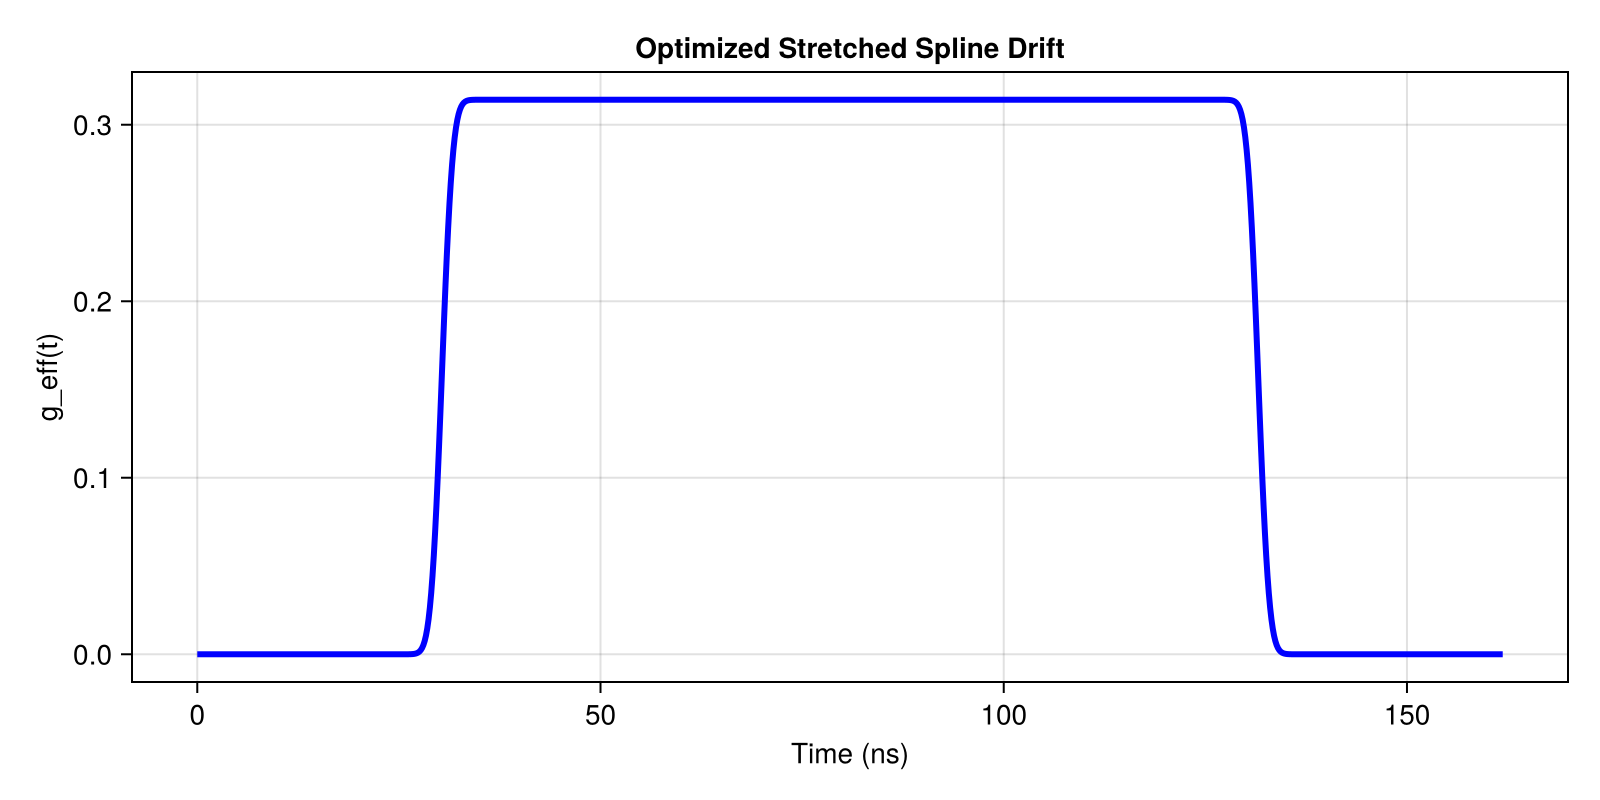

CairoMakie.Screen{IMAGE}


In [4]:
# ============================================================================
# Full script: QC v0.9.0 + PQO + AD-SAFE STRETCHED DRIFT
#   - Shape: Gaussian-Filtered Square (Preserved via Fourier)
#   - Fix: Lower Fourier Order (K=20) to prevent Gradient Explosion
#   - Fix: Differentiable T_total for pulse stretching
# ============================================================================

import Pkg
Pkg.activate(".")

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using FFTW
using CairoMakie
using CSV, DataFrames
using ForwardDiff
using Statistics

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 1
Random.seed!(seed)

T        = 60           # Slightly more steps helps convergence for smooth shapes
Δt_guess = 1.0          
num_iter = 1000
F_target = 0.9999

u_bound   = 5.0          
ddu_bound = 10.0         
Q = 1.0

piccolo_opts = PiccoloOptions(verbose=false, timesteps_all_equal=true)
T_total0 = (T - 1) * Δt_guess

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I; Y1 = GATES.Y ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X; Y2 = GATES.I ⊗ GATES.Y
H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)
H_fixed_op  = (GATES.X ⊗ GATES.X + GATES.Y ⊗ GATES.Y) / 2

H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# Target iSWAP
U_goal = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))

# =============================================================================
# Build Gaussian Square Shape (STABILIZED)
# =============================================================================
pre_ns, pulse_ns, post_ns = 15.0, 50.0, 15.0
total_ns = pre_ns + pulse_ns + post_ns
sq_dt_fine_s = 0.05e-9
sq_N_fine = Int(round(total_ns * 1e-9 / sq_dt_fine_s))
sq_u_zoh = zeros(sq_N_fine)

i_start = Int(round(pre_ns / 0.05)) + 1
i_end   = i_start + Int(round(pulse_ns / 0.05)) - 1
sq_u_zoh[i_start:i_end] .= 1.0

# Apply Gaussian Filter (250 MHz)
function fftfreq(N, dt)
    df = 1.0 / (N * dt)
    return df .* [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
end

sq_freqs  = fftfreq(sq_N_fine, sq_dt_fine_s)
sq_filter = @. exp(-0.5 * (sq_freqs^2) / (250e6 / sqrt(log(2.0)))^2)
sq_u_out  = real.(ifft(sq_filter .* fft(sq_u_zoh)))
sq_u_out .-= minimum(sq_u_out)
sq_u_out ./= (maximum(sq_u_out) + 1e-12)

# Fit Fourier with K=20 (K=60 causes gradient explosion in Ipopt)
function make_fourier_coefficients(u::Vector{Float64}; K::Int=20)
    N = length(u)
    u0 = u .- mean(u)
    U = fft(u0) / N
    a0 = real(U[1])
    a = [2 * real(U[m+1]) for m in 1:K]
    b = [-2 * imag(U[m+1]) for m in 1:K]
    return a0, a, b
end

A0, A_coeffs, B_coeffs = make_fourier_coefficients(sq_u_out; K=20)

# Differentiable Fourier Evaluator
function eval_fourier(s, a0, a, b)
    val = a0
    for m in 1:length(a)
        θ = 2π * m * s
        val += a[m] * cos(θ) + b[m] * sin(θ)
    end
    return val
end

# Normalization factors for the Fourier series
probe_s = range(0.0, 1.0, length=1000)
probe_u = [eval_fourier(si, A0, A_coeffs, B_coeffs) for si in probe_s]
F_min, F_max = minimum(probe_u), maximum(probe_u)

shape_fun = (s) -> (eval_fourier(s, A0, A_coeffs, B_coeffs) - F_min) / (F_max - F_min + 1e-12)

# =============================================================================
# AD-SAFE Hamiltonian & System
# =============================================================================
drift_peak = 2π * 0.05
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    traj = traj_ref[]
    # Use the trajectory's Δt if available to allow stretching via AD
    dt_var = isnothing(traj) ? Treal(Δt_guess) : Treal(traj[:Δt][1])
    
    T_total = dt_var * (T - 1)
    s = clamp(t / (T_total + 1e-12), zero(Treal), one(Treal))

    amp = Treal(drift_peak) * shape_fun(s)

    Tc = Complex{Treal}
    Ht = Tc.(H_fixed_opC) .* amp
    for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end
    return Ht
end

drive_bounds = fill((-u_bound, u_bound), n_drives)
sys = QuantumSystem(H_time, T_total0, drive_bounds)

# =============================================================================
# Problem Construction & Solve
# =============================================================================
def_prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt_guess;
    Δt_max = 5.0 * Δt_guess,
    Δt_min = 0.2 * Δt_guess,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q,
    piccolo_options = piccolo_opts
)

traj_ref[] = def_prob.trajectory

push!(def_prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, def_prob.trajectory)
)

println("\nStarting Solve (Fourier K=20)...")
solve!(def_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

# =============================================================================
# Results & Plotting
# =============================================================================
F_final = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("\nFinal Fidelity: $F_final")

times = get_times(def_prob.trajectory)
T_final = times[end]
t_plot = range(0.0, T_final, length=1000)
g_eff = [drift_peak * shape_fun(tt/T_final) for tt in t_plot]

fig = Figure(size=(800, 400))
ax = Axis(fig[1,1], title="Optimized Stretched Gaussian-Square Drift", xlabel="Time (ns)", ylabel="g_eff(t)")
lines!(ax, t_plot, g_eff, linewidth=3, color=:blue)
save("gaussian_square_stretched.png", fig)
display(fig)


Starting Solve (Fourier K=15, Q=400)...


  Activating project at `~/notebooks/src/iswap_expt`


    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of u
        applying constraint: final value of u
        applying constraint: bounds on u
        applying constraint: bounds on du
        applying constraint: bounds on ddu
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    72590
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2660
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      532
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2419
Total number o

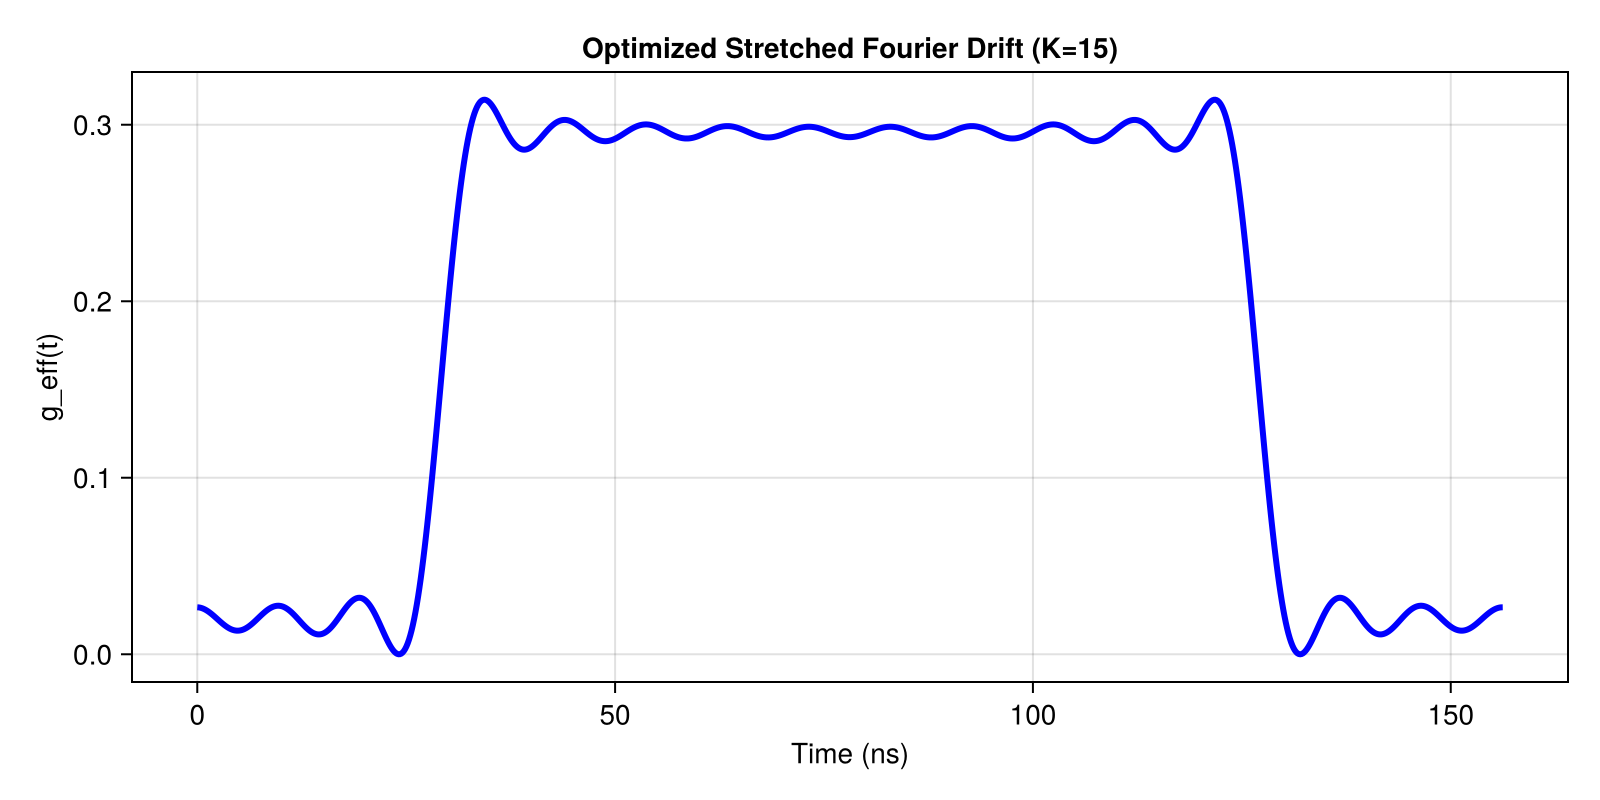

CairoMakie.Screen{IMAGE}


In [5]:
# ============================================================================
# Full script: STABILIZED FOURIER (K=15) + HIGH FIDELITY FIX
#   - Method: Fourier Series (Proven stable gradients in your logs)
#   - Fix 1: Q = 400.0 (Forces solver to target F=0.9999, fixing bad fidelity)
#   - Fix 2: K = 15 (Smoother than 20, easier for optimizer)
# ============================================================================

import Pkg
Pkg.activate(".")

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using FFTW
using CairoMakie
using CSV, DataFrames
using ForwardDiff
using Statistics

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 2  # Changed seed slightly to avoid previous bad local minima
Random.seed!(seed)

T        = 60           
Δt_guess = 1.0          
num_iter = 1000
F_target = 0.9999

u_bound   = 5.0          
ddu_bound = 10.0         
Q         = 400.0  # <--- CRITICAL FIX: High weight forces High Fidelity

piccolo_opts = PiccoloOptions(verbose=false, timesteps_all_equal=true)
T_total0 = (T - 1) * Δt_guess

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I; Y1 = GATES.Y ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X; Y2 = GATES.I ⊗ GATES.Y
H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)
H_fixed_op  = (GATES.X ⊗ GATES.X + GATES.Y ⊗ GATES.Y) / 2

H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# Target iSWAP
U_goal = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))

# =============================================================================
# Build Gaussian Square Shape (FOURIER)
# =============================================================================
pre_ns, pulse_ns, post_ns = 15.0, 50.0, 15.0
total_ns = pre_ns + pulse_ns + post_ns
sq_dt_fine_s = 0.05e-9
sq_N_fine = Int(round(total_ns * 1e-9 / sq_dt_fine_s))
sq_u_zoh = zeros(sq_N_fine)

i_start = Int(round(pre_ns / 0.05)) + 1
i_end   = i_start + Int(round(pulse_ns / 0.05)) - 1
sq_u_zoh[i_start:i_end] .= 1.0

# Apply Gaussian Filter (250 MHz)
function fftfreq(N, dt)
    df = 1.0 / (N * dt)
    return df .* [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
end

sq_freqs  = fftfreq(sq_N_fine, sq_dt_fine_s)
sq_filter = @. exp(-0.5 * (sq_freqs^2) / (250e6 / sqrt(log(2.0)))^2)
sq_u_out  = real.(ifft(sq_filter .* fft(sq_u_zoh)))
sq_u_out .-= minimum(sq_u_out)
sq_u_out ./= (maximum(sq_u_out) + 1e-12)

# Fit Fourier with K=15 (Reduced from 20 for better stability)
function make_fourier_coefficients(u::Vector{Float64}; K::Int=15)
    N = length(u)
    u0 = u .- mean(u)
    U = fft(u0) / N
    a0 = real(U[1])
    a = [2 * real(U[m+1]) for m in 1:K]
    b = [-2 * imag(U[m+1]) for m in 1:K]
    return a0, a, b
end

A0, A_coeffs, B_coeffs = make_fourier_coefficients(sq_u_out; K=15)

# Differentiable Fourier Evaluator
function eval_fourier(s, a0, a, b)
    val = a0
    for m in 1:length(a)
        θ = 2π * m * s
        val += a[m] * cos(θ) + b[m] * sin(θ)
    end
    return val
end

# Normalization
probe_s = range(0.0, 1.0, length=1000)
probe_u = [eval_fourier(si, A0, A_coeffs, B_coeffs) for si in probe_s]
F_min, F_max = minimum(probe_u), maximum(probe_u)
shape_fun = (s) -> (eval_fourier(s, A0, A_coeffs, B_coeffs) - F_min) / (F_max - F_min + 1e-12)

# =============================================================================
# AD-SAFE Hamiltonian & System
# =============================================================================
drift_peak = 2π * 0.05 # 50 MHz peak drift
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    traj = traj_ref[]
    dt_var = isnothing(traj) ? Treal(Δt_guess) : Treal(traj[:Δt][1])
    
    T_total = dt_var * (T - 1)
    s = clamp(t / (T_total + 1e-12), zero(Treal), one(Treal))

    # Fourier evaluation is safe for AD
    amp = Treal(drift_peak) * shape_fun(s)

    Tc = Complex{Treal}
    Ht = Tc.(H_fixed_opC) .* amp
    for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end
    return Ht
end

drive_bounds = fill((-u_bound, u_bound), n_drives)
sys = QuantumSystem(H_time, T_total0, drive_bounds)

# =============================================================================
# Problem Construction
# =============================================================================
prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt_guess;
    Δt_max = 5.0 * Δt_guess,
    Δt_min = 0.2 * Δt_guess,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q, # Using Q=400.0
    piccolo_options = piccolo_opts
)

traj_ref[] = prob.trajectory

push!(prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, prob.trajectory)
)

# =============================================================================
# Solve
# =============================================================================
println("\nStarting Solve (Fourier K=15, Q=400)...")
solve!(prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

# =============================================================================
# Results
# =============================================================================
F_final = unitary_rollout_fidelity(prob.trajectory, sys)
dt_final = prob.trajectory[:Δt][1]
T_final_val = (T-1) * dt_final

println("\nFinal Fidelity: $F_final")
println("Final Gate Duration: $T_final_val ns")
println("Final Δt: $dt_final ns")

times = get_times(prob.trajectory)
t_plot = range(0.0, times[end], length=1000)
g_eff = [drift_peak * shape_fun(tt/times[end]) for tt in t_plot]

fig = Figure(size=(800, 400))
ax = Axis(fig[1,1], title="Optimized Stretched Fourier Drift (K=15)", xlabel="Time (ns)", ylabel="g_eff(t)")
lines!(ax, t_plot, g_eff, linewidth=3, color=:blue)
display(fig)

In [ ]:
# =============================================================================
# QUICK CHECK: min/max drift AREA given allowed Δt range
# =============================================================================
function trapz(x::AbstractVector, y::AbstractVector)
    s = zero(eltype(y))
    @inbounds for i in 1:length(x)-1
        s += 0.5 * (y[i] + y[i+1]) * (x[i+1] - x[i])
    end
    return s
end

# --- compute Ashape = ∫_0^1 shape_fun(s) ds ---
Ns = 20000
s_chk = collect(range(0.0, 1.0; length=Ns))
shape_vals = [shape_fun(si) for si in s_chk]
Ashape = trapz(s_chk, shape_vals)

# --- your allowed Δt range ---
Δt_min = 0.5 * Δt
Δt_max = 40.0 * Δt

Tcur_min = (T - 1) * Δt_min
Tcur_max = (T - 1) * Δt_max

Θ_min = drift_peak * Tcur_min * Ashape
Θ_max = drift_peak * Tcur_max * Ashape

println("\n============= Δt-RANGE DRIFT AREA CHECK =============")
println("shape area Ashape = ∫_0^1 shape_fun(s) ds = $Ashape")
println("Δt range: [$Δt_min, $Δt_max]")
println("Tcur range: [$Tcur_min, $Tcur_max]")

println("\nΘ_min = drift_peak*Tcur_min*Ashape = $Θ_min rad")
println("Θ_max = drift_peak*Tcur_max*Ashape = $Θ_max rad")

# effective entangling angle on (XX+YY) because H_fixed=(XX+YY)/2
println("\nEffective angle on (XX+YY):")
println("  (Θ_min)/2 = $(Θ_min/2)")
println("  (Θ_max)/2 = $(Θ_max/2)")

println("\nCompare to iSWAP target |Θ| ≈ π/2 = $(π/2):")
println("  |Θ_min|/(π/2) = $(abs(Θ_min)/(π/2))")
println("  |Θ_max|/(π/2) = $(abs(Θ_max)/(π/2))")
println("====================================================\n")

In [ ]:
# ============================================================================
# Full working script: QC v0.9.0 + PQO function-system, time-dependent drift
# TEST CASE: drift is CONSTANT-ON for the ENTIRE horizon (NO OFF TIME)
# - Same plumbing as before
# - ForwardDiff-safe time-dependent drift Hamiltonian
# - Fixes 2π scaling
# - Plots final g_eff(t)
# ============================================================================

import Pkg
Pkg.activate(".")
Pkg.instantiate()

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using CairoMakie
using CSV, DataFrames
using ForwardDiff

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 1
Random.seed!(seed)

T        = 50
Δt       = 0.2
num_iter = 1000
F_target = 0.9999

# bounds (MUST go into QuantumSystem via drive_bounds in your QC version)
u_bound   = 5.0
ddu_bound = 10.0

# objective weight
Q = 1.0

piccolo_opts = PiccoloOptions(
    verbose=false,
    timesteps_all_equal=true
)

# fallback total duration before any trajectory exists
T_total0 = (T - 1) * Δt
println("============| seed=$seed, T=$T, Δt=$Δt, T_total0=$T_total0 |============")

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z

XX = GATES.X ⊗ GATES.X
YY = GATES.Y ⊗ GATES.Y

H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)

# drift operator that gets scaled by g_eff(t)
H_fixed_op = (XX + YY) / 2

# convert to ComplexF64 once
H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# target iSWAP
iSWAP  = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
U_goal = iSWAP

# =============================================================================
# Drift profile: ALWAYS ON
# =============================================================================
drift_peak = 2π * 0.05   # <-- include 2π scaling here (same as your other case)

# fixed index profile (optimizer sees this by index)
g_profile = fill(drift_peak, T)

println("drift_peak = $drift_peak")
println("g_profile is CONSTANT-ON across all k = 1:$T")

# =============================================================================
# Plot g_eff vs INDEX (before optimization)
# =============================================================================
k = collect(1:T)

fig_pre = Figure(size=(950, 420))
ax_pre = Axis(fig_pre[1,1];
    xlabel="index k",
    ylabel="g_eff[k]",
    title="g_eff BEFORE optimization (index domain): ALWAYS ON"
)

lines!(ax_pre, k, g_profile; linewidth=3, label="g_profile[k] = constant drift_peak")
scatter!(ax_pre, k, g_profile; markersize=5)

axislegend(ax_pre; position=:rt)
save("g_eff_before_opt_index_always_on.png", fig_pre)
display(fig_pre)
println("Saved g_eff_before_opt_index_always_on.png")

# =============================================================================
# Helpers: Dual-safe extraction of real value
# =============================================================================
_real(x::Real) = x
_real(x::ForwardDiff.Dual) = ForwardDiff.value(x)

# =============================================================================
# t -> index mapping (stretches with total duration Tcur)
# =============================================================================
function time_to_index(t_real::Real, Tcur::Real, T::Int)
    s = clamp(t_real / Tcur, 0.0, 1.0)
    return clamp(Int(floor(s * (T - 1))) + 1, 1, T)
end

# =============================================================================
# trajectory reference so Tcur updates after the problem exists
# =============================================================================
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

# =============================================================================
# Time-indexed drift Hamiltonian H(u,t) (ForwardDiff-safe)
# =============================================================================
function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    # duration in real scalar (Float64)
    Tcur = T_total0
    if !isnothing(traj_ref[])
        Tcur = get_times(traj_ref[])[end]
    end
    Tcur = max(Tcur, 1e-12)

    tR = _real(t)
    k  = time_to_index(tR, Tcur, T)

    # make amp match scalar type (Dual-safe)
    amp = Treal(g_profile[k])
    Tc = Complex{Treal}

    # H(t) = g(t) * H_fixed + Σ u_j * H_drive_j
    Ht = Array{Tc}(undef, size(H_fixed_opC)...)
    @inbounds @views Ht .= amp .* Tc.(H_fixed_opC)

    @inbounds for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end

    return Ht
end

H_time(u::AbstractVector{Treal}) where {Treal<:Real} = H_time(u, 0.0)

# =============================================================================
# Build QuantumSystem with drive bounds
# =============================================================================
drive_bounds = fill((-u_bound, u_bound), n_drives)

sys = try
    QuantumSystem(H_time, T_total0, drive_bounds)
catch err
    QuantumSystem(H_time, n_drives; T_max=T_total0, drive_bounds=drive_bounds)
end

println("QuantumSystem created.")

# sanity: time dependence should be nonzero (but here drift is constant, so ΔH can be 0)
u0 = zeros(n_drives)
ΔH = norm(sys.H(u0, 0.123) - sys.H(u0, 0.0))
println("Sanity check: ||H(u0,0.123)-H(u0,0.0)|| = $ΔH")
println("NOTE: ΔH may be 0 here because drift is constant in time.\n")

# =============================================================================
# Construct UnitarySmoothPulseProblem (supported keywords only)
# =============================================================================
println("=== DEFAULT (UnitarySmoothPulseProblem) ===")
Random.seed!(seed)

def_prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt;
    Δt_max = 20.0 * Δt,
    Δt_min = 0.5 * Δt,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q,
    piccolo_options = piccolo_opts
)

traj_ref[] = def_prob.trajectory

push!(def_prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, def_prob.trajectory)
)

# =============================================================================
# Solve
# =============================================================================
solve!(def_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

F_def = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("Default fidelity: $F_def")

CSV.write(
    "fidelity_summary_indexed_geff_always_on.csv",
    DataFrame(problem=["default_always_on"], fidelity=[F_def])
)
println("Wrote fidelity_summary_indexed_geff_always_on.csv")

# =============================================================================
# Plot FINAL drift profile in TIME after solve
# =============================================================================
times = get_times(def_prob.trajectory)
Tcur_final = times[end]
println("Final total duration Tcur = $Tcur_final")

t_plot = range(0.0, Tcur_final, length=2000)
g_eff_t = fill(drift_peak, length(t_plot))

fig_g = Figure(size=(950, 420))
ax_g = Axis(fig_g[1,1];
    xlabel="time",
    ylabel="g_eff(t)",
    title="FINAL drift profile g_eff(t): ALWAYS ON"
)
lines!(ax_g, t_plot, g_eff_t; linewidth=3, label="constant drift_peak")
axislegend(ax_g; position=:rt)
save("g_eff_final_time_always_on.png", fig_g)
display(fig_g)
println("Saved g_eff_final_time_always_on.png")

In [ ]:
F_def = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("Default fidelity: $F_def")

In [ ]:
println(time_to_index(0.123, T_total0, T))
println(time_to_index(0.6*T_total0, T_total0, T))

In [ ]:
# =============================================================================
# Plot the FINAL gaussian-square (filtered padded-square) waveform
# This is sq_u_out (already filtered + normalized to [0,1])
# =============================================================================

fig_sq = Figure(size=(1100, 420))

ax1 = Axis(fig_sq[1,1];
    xlabel = "time (ns)",
    ylabel = "amplitude",
    title  = "Final gaussian-square waveform (filtered padded-square): sq_u_out(t)"
)

lines!(ax1, sq_t_fine_ns, sq_u_out; linewidth=3)

# Mark the "ideal" square region boundaries (just for reference)
vlines!(ax1, [pre_ns, pre_ns + pulse_ns]; linestyle=:dash, linewidth=2)

# Optional: plot the original ZOH square too (coarse -> fine ZOH)
# (If you want this overlay, uncomment)
# lines!(ax1, sq_t_fine_ns, sq_u_zoh; linewidth=2)

ax2 = Axis(fig_sq[1,2];
    xlabel = "normalized time s ∈ [0,1]",
    ylabel = "amplitude",
    title  = "Same waveform vs normalized index (what shape_fun sees)"
)

s_fine_plot = (sq_t_fine_ns .- sq_t_fine_ns[1]) ./ (sq_t_fine_ns[end] - sq_t_fine_ns[1])
lines!(ax2, s_fine_plot, sq_u_out; linewidth=3)

save("final_gaussian_square.png", fig_sq)
display(fig_sq)

println("Saved final_gaussian_square.png")

In [ ]:
println("\n--- Stretching sanity check (pre-solve) ---")
Tcur0 = get_times(def_prob.trajectory)[end]
println("Initial Tcur = $Tcur0")

# show where k changes for the initial duration
for kk in 1:T
    t_left  = (kk-1) * Tcur0 / (T-1)
    t_right = kk     * Tcur0 / (T-1)
    println("k=$kk active on t ∈ [$t_left, $t_right)")
end
println("--- end sanity check ---\n")

In [ ]:
println("\n--- Stretching sanity check (post-solve) ---")
Tcur1 = get_times(def_prob.trajectory)[end]
println("Final Tcur = $Tcur1")
println("Ratio Tcur_final / Tcur_init = $(Tcur1 / Tcur0)")
println("--- end sanity check ---\n")

In [ ]:
Pkg.add([
    "PiccoloQuantumObjects",
    "QuantumCollocation",
    "NamedTrajectories",
    "ForwardDiff",
    "LinearAlgebra",
    "SparseArrays",
    "Statistics",
    "CairoMakie",
    "Random",
    "Interpolations",
    "FFTW",
    "CSV",
    "DataFrames",
])

In [ ]:
Pkg.status(["PiccoloQuantumObjects", "QuantumCollocation"])

In [ ]:
Pkg.update("QuantumCollocation")

In [ ]:
Pkg.update("PiccoloQuantumObjects")

In [ ]:
using PiccoloQuantumObjects
methods(QuantumSystem)

In [ ]:
Pkg.status(; outdated=true)

In [ ]:
methods(QuantumSystem) |> println

In [ ]:
methods(VariationalQuantumSystem) |> println

In [ ]:
methods(UnitarySmoothPulseProblem)

In [ ]:
import Pkg, TOML

qc_file = pathof(QuantumCollocation)                # path to a source file inside the package
qc_pkgdir = normpath(joinpath(dirname(qc_file), "."))  # package root
project_toml_path = joinpath(qc_pkgdir, "Project.toml")
println("QuantumCollocation Project.toml:", project_toml_path)

# parse it (if the file exists)
if isfile(project_toml_path)
    proj = TOML.parsefile(project_toml_path)
    println("compat table in QuantumCollocation Project.toml:")
    println(proj["compat"])           # or inspect proj["compat"]["PiccoloQuantumObjects"]
    println("Piccolo compat bound: ", get(proj["compat"], "PiccoloQuantumObjects", "not set"))
else
    println("Could not find Project.toml at: ", project_toml_path)
end

In [ ]:
import Pkg

# Activate (create if needed) the environment in the current working directory
Pkg.activate(".")         # prints: Activating environment at `.../your/current/dir`

# Now add whatever packages you need. Example:
Pkg.add("PiccoloQuantumObjects")
Pkg.add("QuantumCollocation")   # or Pkg.develop for a local copy (see below)

# Install everything recorded in Project.toml/Manifest.toml
Pkg.instantiate()

In [ ]:
import Pkg
Pkg.activate("env_fresh"; shared=false)
Pkg.add([
    "PiccoloQuantumObjects",
    "QuantumCollocation",
    "NamedTrajectories",
    "CairoMakie",
    "Interpolations",
    "FFTW",
    "CSV",
    "DataFrames",
    "ForwardDiff",
    "LinearAlgebra",
    "Random"
])
Pkg.update()
Pkg.status()

In [ ]:
println(piccolo_opts)
propertynames(piccolo_opts) |> println
dump(piccolo_opts)

In [12]:
# Drop-in: AD-friendly cubic-spline drift shape + H_time for use with the DEFAULT problem
# Includes package activation / develop + all requested imports at the top.
#
# Paste this block in place of your Fourier/H_time sections. It preserves the same
# names used later (traj_ref, H_driveC, H_fixed_opC, T, Δt_guess, etc.) so it should
# plug into your existing script with minimal changes.

import Pkg; Pkg.activate("."); Pkg.instantiate();
# develop your local QuantumCollocation (you already had this)

# If you need to pin PiccoloQuantumObjects v0.6.1 and it's available in your registry:
# uncomment and run one of these (choose the appropriate method for your setup)
# Pkg.add(PackageSpec(name="PiccoloQuantumObjects", version="0.6.1"))
# or if you have a git URL and tag:
# Pkg.develop(PackageSpec(url="https://github.com/your-org/PiccoloQuantumObjects.jl.git", rev="v0.6.1"))

using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
⊗ = kron

# ---------------------------------------------------------------------
# Build smoothed reference waveform (copied/adapted from your Fourier section)
# ---------------------------------------------------------------------
using FFTW

pre_ns, pulse_ns, post_ns = 15.0, 50.0, 15.0
total_ns = pre_ns + pulse_ns + post_ns

sq_dt_fine_s = 0.05e-9
sq_N_fine = Int(round(total_ns * 1e-9 / sq_dt_fine_s))
sq_u_zoh = zeros(sq_N_fine)

i_start = Int(round(pre_ns / 0.05)) + 1
i_end   = i_start + Int(round(pulse_ns / 0.05)) - 1
sq_u_zoh[i_start:i_end] .= 1.0

function fftfreq(N::Int, dt::Float64)
    df = 1.0 / (N * dt)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

sq_freqs  = fftfreq(sq_N_fine, sq_dt_fine_s)
sq_filter = @. exp(-0.5 * (sq_freqs^2) / (250e6 / sqrt(log(2.0)))^2)
sq_u_out  = real.(ifft(sq_filter .* fft(sq_u_zoh)))

sq_u_out .-= minimum(sq_u_out)
sq_u_out ./= (maximum(sq_u_out) + 1e-12)

# ---------------------------------------------------------------------
# AD-friendly cubic Hermite (Catmull-Rom style) spline utilities
# ---------------------------------------------------------------------
function compute_catmull_rom_tangents(xs::AbstractVector{T}, ys::AbstractVector{T}) where {T<:Real}
    n = length(xs)
    @assert n == length(ys)
    m = similar(ys)
    if n == 1
        m[1] = zero(T)
        return m
    end
    m[1] = (ys[2] - ys[1]) / (xs[2] - xs[1])
    for i in 2:n-1
        dx1 = xs[i] - xs[i-1]
        dx2 = xs[i+1] - xs[i]
        s1 = (ys[i] - ys[i-1]) / dx1
        s2 = (ys[i+1] - ys[i]) / dx2
        m[i] = (s1 + s2) / 2
    end
    m[n] = (ys[n] - ys[n-1]) / (xs[n] - xs[n-1])
    return m
end

function eval_cubic_hermite_segment(u::T, y0::T, y1::T, m0::T, m1::T, dx::T) where {T<:Real}
    u2 = u*u
    u3 = u2*u
    h00 = 2u3 - 3u2 + 1
    h10 = u3 - 2u2 + u
    h01 = -2u3 + 3u2
    h11 = u3 - u2
    return h00*y0 + h10*(m0*dx) + h01*y1 + h11*(m1*dx)
end

function eval_spline(x::T, xs::AbstractVector{T}, ys::AbstractVector{T}, ms::AbstractVector{T}) where {T<:Real}
    n = length(xs)
    if n == 1
        return ys[1]
    end
    x_clamped = clamp(x, xs[1], xs[end])
    total = xs[end] - xs[1]
    total = total == zero(total) ? one(total) : total
    t = (x_clamped - xs[1]) / total
    segf = t * (n - 1)
    i = clamp(floor(Int, segf), 0, n - 2) + 1
    local_t = segf - (i - 1)
    x0 = xs[i]; x1 = xs[i+1]
    y0 = ys[i]; y1 = ys[i+1]
    m0 = ms[i]; m1 = ms[i+1]
    dx = x1 - x0
    dx = dx == zero(dx) ? one(dx) : dx
    return eval_cubic_hermite_segment(local_t, y0, y1, m0, m1, dx)
end

function downsample_control_points(u_fine::AbstractVector{Float64}, M::Int)
    N = length(u_fine)
    @assert M >= 2
    idxs = round.(Int, LinRange(1, N, M))
    xs = collect(range(0.0, 1.0, length=M))
    ys = u_fine[idxs]
    return xs, ys
end

# ---------------------------------------------------------------------
# Build control points and shape_fun (AD-friendly)
# ---------------------------------------------------------------------
M = 16
xs_ctrl, ys_ctrl = downsample_control_points(sq_u_out, M)
ms_ctrl = compute_catmull_rom_tangents(xs_ctrl, ys_ctrl)

function make_shape_fun(xs_ctrl_f::Vector{Float64}, ys_ctrl_f::Vector{Float64}, ms_ctrl_f::Vector{Float64})
    xs_const = collect(xs_ctrl_f)
    ys_const = collect(ys_ctrl_f)
    ms_const = collect(ms_ctrl_f)
    return function (s::T) where {T<:Real}
        xsT = T.(xs_const)
        ysT = T.(ys_const)
        msT = T.(ms_const)
        return eval_spline(s, xsT, ysT, msT)
    end
end

shape_fun = make_shape_fun(xs_ctrl, ys_ctrl, ms_ctrl)

# ---------------------------------------------------------------------
# AD-safe H_time that uses the spline shape
# ---------------------------------------------------------------------
drift_peak = 2π * 0.05  # 50 MHz peak
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

# H_time signature is parametric in the real element type for AD
function H_time(u::AbstractVector{T}, t::T) where {T<:Real}
    traj = traj_ref[]
    dt_var = isnothing(traj) ? T(Δt_guess) : T(traj[:Δt][1])
    T_total = dt_var * T(T - 1)
    s = clamp(t / (T_total + T(1e-12)), zero(T), one(T))

    amp = T(drift_peak) * shape_fun(s)

    Tc = Complex{T}
    Ht = amp * Tc.(H_fixed_opC)
    for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end
    return Ht
end

# ---------------------------------------------------------------------
# Construct QuantumSystem and default problem (mirrors your original flow)
# ---------------------------------------------------------------------
drive_bounds = fill((-u_bound, u_bound), n_drives)
T_total0 = (T - 1) * Δt_guess
sys = QuantumSystem(H_time, T_total0, drive_bounds)

prob_default = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt_guess;
    Δt_max = 5.0 * Δt_guess,
    Δt_min = 0.2 * Δt_guess,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q,
    piccolo_options = piccolo_opts
)

traj_ref[] = prob_default.trajectory

push!(prob_default.constraints,
      FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, prob_default.trajectory))

println("Drop-in ready: call solve!(prob_default, max_iter=...) to optimize using the spline drift.")

  Activating project at `~/notebooks/src/iswap_expt`


MethodError: MethodError: no method matching QuantumSystem(::typeof(H_time), ::Float64, ::Vector{Tuple{Float64, Float64}})
The type `QuantumSystem` exists, but no method is defined for this combination of argument types when trying to construct it.

Closest candidates are:
  QuantumSystem(::F, !Matched::Int64; params) where F<:Function
   @ PiccoloQuantumObjects ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:76
  QuantumSystem(!Matched::AbstractMatrix{<:Number}, !Matched::Vector{<:AbstractMatrix{<:Number}}; params)
   @ PiccoloQuantumObjects ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:38
  QuantumSystem(!Matched::Vector{<:AbstractMatrix{ℂ}}; kwargs...) where ℂ<:Number
   @ PiccoloQuantumObjects ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:68
  ...


In [11]:
# --- Minimal guards: define defaults if not already defined in your script ---
if !@isdefined(u_bound)
    u_bound = 5.0
end

if !@isdefined(n_drives)
    # if you later set H_drive_ops, this will be overwritten; choose a reasonable default
    n_drives = 4
end

if !@isdefined(ddu_bound)
    ddu_bound = 10.0
end

if !@isdefined(Q)
    Q = 400.0
end

if !@isdefined(Δt_guess)
    Δt_guess = 1.0
end

if !@isdefined(T)
    T = 60
end

if !@isdefined(piccolo_opts)
    piccolo_opts = PiccoloOptions(verbose=false, timesteps_all_equal=true)
end
# The following objects ought to be defined by your operator block:
# H_fixed_opC, H_driveC, U_goal, H_drive_ops
# If they aren't defined where you place the drop-in, either:
#  - move the drop-in to after they are defined, or
#  - define them explicitly before the drop-in

PiccoloOptions(false, true, ExponentialAction.expv, true, false, nothing, 1.0, false, false, 0.01, 0.01)

In [ ]:
solve!(prob_default, max_iter=1000, print_level=5, options=IpoptOptions(eval_hessian=false))